# Restaurant Row Behaviour: Quantifying Learning 

_Goal_: plot various metrics for evaluating performance of mice in RR.
- Quantify statistics of different trial types, learning across sessions and how restaurant flavour preferences influence likelhood of choices

Create df with exp info: 
- session info: `animal ID`, `day`, `epoch`
- overview: `# of pellets/hour`, `median inter pellet interval ipi`, `total time in RR`, `num of laps`
- learning: `no reward dwell time`, `reject event count`, `reject accuracy`

### Outcome Types

- `reject`: left turn, reject offer
- `quit`: right turn, quit before reward tone
- `reward_taken`: right turn accept, reward offered and taken
- `reward_available`:  right turn accept - reward offered but not taken 
- `reward_omission`: right turn accept, no-reward 

### Trial Types to Compare Across
- 4 restaurants with 4 offer tones = 16 event types

In [1]:
#import packages
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import os
import re
import matplotlib as mpl
from matplotlib import rc

#import functions
from main import *
from behaviour_functions.helper_functions import *
from behaviour_functions.plotting_functions import *

# # specify plotting params
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
# mpl.rcParams['font.family'] = "sans-serif"
# mpl.rcParams['pdf.fonttype'] = 42
# mpl.rcParams['ps.fonttype'] = 42
# #rc('text', usetex=False)
# mpl.rcParams['axes.spines.right'] = False
# mpl.rcParams['axes.spines.top'] = False
# plt.rcParams.update({'font.size': 16})
# plt.rcParams["figure.figsize"] = (10, 6)  # (w, h)

In [2]:
# load sessions folder for RRMxxx

path_RM011 = '../RR_Behavior_Data/RRM_011/'
data_RM011 = load_behavior(path_RM011)
path_RM022 = '../RR_Behavior_Data/RRM_022/'
data_RM022 = load_behavior(path_RM022)
path_RM025 = '../RR_Behavior_Data/RRM_025/'
data_RM025 = load_behavior(path_RM025)

# for troubleshooting
# files = listdir_nohidden(path_RM025)
# df = pd.read_csv(path_RM011+files[8],sep=' ',header=None,names = ['time','b_code','none'])
# df = crop_time(df)

In [3]:
%matplotlib inline

#Choose mouse to plot 
data = data_RM022

Text(0.5, 1.0, 'Epoch vs Day')

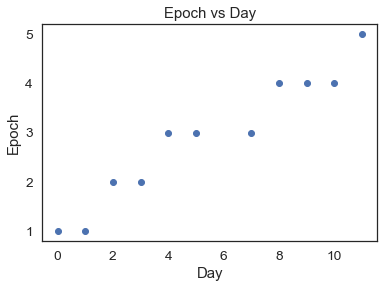

In [4]:
plt.plot(data.day,data.epoch,'o')
plt.xlabel('Day')
plt.ylabel('Epoch')
plt.title('Epoch vs Day')

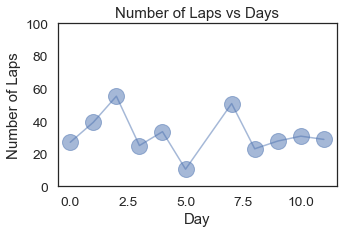

In [5]:
plot_laps(data)

(1.0, 11.0)

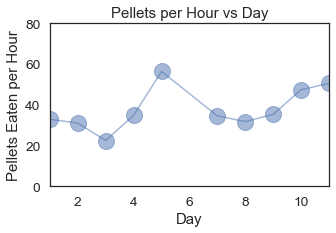

In [6]:
plot_pellets(data)
plt.ylim([0,80])
plt.xlim([1,11])

Text(0.5, 1.0, 'Median Interpellet Interval vs Days')

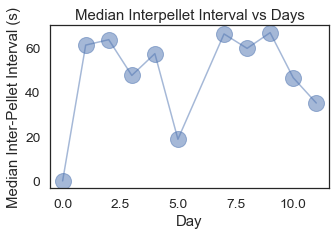

In [7]:
plot_iti(data)
plt.title('Median Interpellet Interval vs Days')

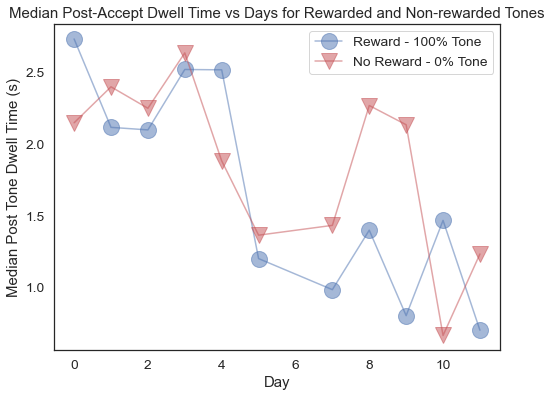

In [8]:
plot_dwell(data)

Rejection events per day: [17 16 34 15 21 8 46 18 34 23 17]


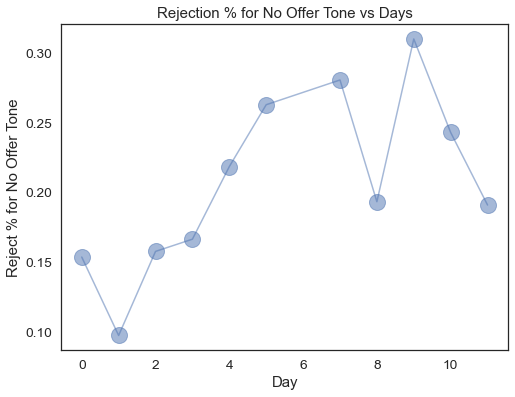

In [9]:
plot_rejections(data)

## To Do: 

- [in progress]  function for calculating proportion of different outcomes
- plot proprtion of reject/quit across days

In [10]:
'''
Function for Identifying different Outcome Types 
'''
# Event Codes

zero_offer_tone_codes = [17,29,41,53] # no-reward tone codes - 0%
twenty_offer_tone_codes = [18,30,42,54]
eighty_offer_tone_codes = [19,31,43,55]
hundy_offer_tone_codes = [20,32,44,56] # reward tone codes - 100%

rwd_omission_codes=[15, 27, 39, 51] # accept, reward not offered
rwd_taken_codes = [16, 28, 40, 52] # accept, reward offered + taken

sharp_exit_codes = [63,66,69,72] # Exit codes, aka "Sharp" timestamps
sharp_entry_codes = [61,64,67,70] #Entry codes, aka "Sharp"
sharp_accept_codes = [62,65,68,71] #Sharp accept codes

servo_opened_codes =[1, 3, 5, 7]
servo_closed_codes =[2, 4, 6, 8]
enter_codes =[11, 23, 35, 47]
reject_codes =[12, 24, 36, 48]


# initialize things
r_num = 4
tone_num=4

reward_taken=np.zeros(r_num)
reward_available=np.zeros(r_num)
reward_omission=np.zeros(r_num)
quit= np.zeros(r_num)
reject= np.zeros(r_num)

outcome_types = pd.DataFrame(columns=['reject','quit','rwd_omission', 'rwd_available','rwd_taken'])

for rr in [1,2,3,4]:
    zero_tone_idx = df.index[df.b_code.isin([zero_offer_tone_codes[rr-1]])].values
    hundy_tone_idx = df.index[df.b_code.isin([hundy_offer_tone_codes[rr-1]])].values
    
    tone_idx = np.append(offer_tone_idx,no_offer_tone_idx)
    accept_idx = df.index[df.b_code.isin([accept_codes[rr-1]])].values
    exit_idx = df.index[df.b_code.isin([exit_codes[rr-1]])].values
    entry_idx = df.index[df.b_code.isin([entry_codes[rr-1]])].values

NameError: name 'df' is not defined

In [ ]:
# Looking at single behavior file for troubleshooting
file = 'RR_Day019_epoch-4_ID-A2A18DRV_2020-11-09T15_01_41.csv'
data = pd.read_csv(file,sep=' ',header=None,names = ['time','b_code','none'])

In [ ]:
%matplotlib widget
exit_codes = [63,66,69,72] # Exit codes 
entry_codes = [61,64,67,70] # Entry codes
accept_codes = [62,65,68,71] # Accept codes
entry_codes = [61] # Entry codes
exit_codes = [63] # Exit codes
accept_codes = [62] #Sharp accept codes
time_stamps_exit = data.time[data.b_code.isin(exit_codes)]
time_stamps_entry = data.time[data.b_code.isin(entry_codes)]
time_stamps_accept = data.time[data.b_code.isin(accept_codes)]
plt.plot(time_stamps_exit/1000,np.ones_like(time_stamps_exit)*3,'o',alpha=0.5,label='exit')
plt.plot(time_stamps_entry/1000,np.ones_like(time_stamps_entry)*1,'o',alpha=0.5,label='entry')
plt.plot(time_stamps_accept/1000,np.ones_like(time_stamps_accept)*2,'o',alpha=0.5,label='accept')
plt.legend()
plt.ylim([-1,5])
plt.xlim([55401,55450])

# Plotting FP Data

In [ ]:
# Build DataFrame containing all behavior data
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import re
import matplotlib as mpl
from matplotlib import rc
from scipy import signal
from IPython.core.debugger import set_trace

from main import *
from fp_functions.helper_functions import *
from fp_functions.plotting_fp import *

In [ ]:
reward_codes_0 = [17, 29, 41, 53]  # no-reward tone codes
reward_codes_20 = [18, 30, 42, 54]  # 20pct rewarded tone codesc
reward_codes_80 = [19, 31, 43, 55]  # 80pct rewarded tone codes
reward_codes_100 = [20, 32, 44, 56]  # reward tone codes
reward_taken_codes = [16, 28, 40, 52]  # Pellet taken from dispenser

servo_open_codes = [1, 3, 5, 7] # Servo arm open = should track with pellets offered
exit_codes = [63, 66, 69, 72]  # Exit codes, aka "Sharp" timestamps
entry_codes = [61, 64, 67, 70]  # Entry codes, aka "Sharp"
accept_codes = [62, 65, 68, 71]  # Sharp accept codes
df = rr_data

In [ ]:
dt

In [ ]:
dt1 = 20
# dt = []
dt.append(dt1)

In [ ]:
for rr in [1, 2, 3, 4]:
    offer_tone_100_idx = df.index[df.b_code.isin(
        [reward_codes_100[rr-1]])].values
    offer_tone_80_idx = df.index[df.b_code.isin(
        [reward_codes_80[rr-1]])].values
    offer_tone_20_idx = df.index[df.b_code.isin(
        [reward_codes_20[rr-1]])].values
    offer_tone_0_idx = df.index[df.b_code.isin(
        [reward_codes_0[rr-1]])].values

    tone_idx = np.append(offer_tone_100_idx, offer_tone_80_idx)
    tone_idx = np.append(tone_idx, offer_tone_20_idx)
    tone_idx = np.append(tone_idx, offer_tone_0_idx)

    #find sharp entry, accept and exit codes for each rstrnt
    accept_idx = df.index[df.b_code.isin([accept_codes[rr-1]])].values
    exit_idx = df.index[df.b_code.isin([exit_codes[rr-1]])].values
    entry_idx = df.index[df.b_code.isin([entry_codes[rr-1]])].values
    reward_taken_idx = df.index[df.b_code.isin([reward_taken_codes[rr-1]])].values  # Pellet taken from dispenser
    servo_open_idx = df.index[df.b_code.isin([servo_open_codes[rr-1]])].values # Servo arm open (should track with pellets offered)
    print(reward_taken_idx)
    
    #Print update of pellets revealed vs pellets taken
    print('Pellets Revealed R' + str(rr)+': '+ str(len(servo_open_idx)))
    print('Pellets Eaten R' + str(rr)+': '+ str(len(reward_taken_idx)))

    for event in tone_idx:
        # Determine which offer tone was given for each event
        code = df.b_code[event]
        if code in reward_codes_0:
            tone_prob = 0
        if code in reward_codes_20:
            tone_prob = 20
        if code in reward_codes_80:
            tone_prob = 80
        if code in reward_codes_100:
            tone_prob = 100

        # make sure events (entry, accept, exit, ect.) occurs after tone event (event) (e.g. not last unfinished trial)
        if (np.any(entry_idx > event) & np.any(exit_idx > event) & np.any(servo_open_idx > event)& np.any(reward_taken_idx > event)):
            next_entry_idx = min(entry_idx[entry_idx > event])
            next_accept_idx = min(accept_idx[accept_idx > event])
            next_exit_idx = min(exit_idx[exit_idx > event])
            next_pellet_reveal_idx = min(servo_open_idx[servo_open_idx > event])
            next_reward_taken_idx = min(reward_taken_idx[reward_taken_idx > event])

In [ ]:
# Get files for ms and day 

# Travis's Data
# fp_folder = '/Volumes/Wilbrecht_file_server/Restaurant Row/Data/fp_data/Cohort 3 D1'
# behavior_folder = '/Volumes/Wilbrecht_file_server/Restaurant Row/Data/rr_data/Cohort 3 D1'
# mouse_id = 'RRM001'
# day = 132

# New Data
fp_folder = '/Volumes/Wilbrecht_file_server/LauraG/RR_FP_Data/RRM003'
behavior_folder = '/Volumes/Wilbrecht_file_server/LauraG/RR_Behavior_Data/RRM003'
mouse_id = 'RRM003'
day = 158

# Get files 
(rr_file, fp_file, fp_time_stamps) = get_data_directories(fp_folder, behavior_folder, mouse_id, day)

# Read in files 
fp_data = pd.read_csv(fp_file, skiprows=1, names=[
                   'frame', 'cam_time_stamp', 'flag', 'right_red', 'left_red', 'right_green', 'left_green'])
data_time_stamps = pd.read_csv(
    fp_time_stamps, names=['time_stamps'])

data_fp = pd.concat([fp_data, data_time_stamps.time_stamps], axis=1)
rr_data = pd.read_csv(rr_file, sep=' ', header=None,
                      names=['time', 'b_code', 'none'])

# Classify events and add class to data_rr df
(reject_events,
 accept_and_rewarded_events,
 num_accept_rewarded_events,
 quit_events, num_quit_events,
 pct_no_offer_rejects,
 data_rr) = classify_events(rr_data)

## Get FP Traces 
alignment = 'accept'
channel = 'green'
side = 'left'
condition = 'rewarded'
trigger_mode = 'TRIG1'
split = 'restaurant'

signals, t = grab_fp_traces(alignment, channel, side, condition, data_fp, data_rr, trigger_mode, split)

In [ ]:
## Get FP Traces 
alignment = 'accept'
channel = 'green'
side = 'left'
condition = 'rewarded'
trigger_mode = 'TRIG1'
split = 'restaurant'

signals, t = grab_fp_traces(alignment, channel, side, condition, data_fp, data_rr, trigger_mode, split)

In [ ]:
split = 'all_restaurant'
plot_trial_avg_FP_aligned(signals, t, split, alignment, side, channel, condition)

In [ ]:
def plot_trial_avg_FP_aligned(signals, t, split, alignment, side, channel, condition):
    
    sns.set_theme(style="white", context="notebook", palette='deep', font_scale=1.25)
    color_idx = ['m', 'g', 'b', 'r']
    
    if split == 'none':
        plt.rcParams["figure.figsize"] = (7, 5)  # (w, h)
        fig, axes = plt.subplots()
        sns.set_theme(font_scale=1)
        
        mean_trace = np.mean(signals, axis=0)
#         mean_trace = mean_trace - mean_trace[0]
        SEM_trace = np.std(signals, axis=0)/np.sqrt(len(signals))
        
        axes.plot(t, mean_trace)
        axes.fill_between(t, mean_trace + SEM_trace,mean_trace - SEM_trace, alpha=0.5)
        axes.set_xlabel('Time (s)')
        axes.set_ylabel('FP Signal (a.u)')
        
        ymin, ymax = axes.get_ylim()
        axes.plot([0, 0], [ymin, ymax], '--k')

        fig_title = f"Alignment: {alignment}, Hemi: {side}, Signal: {channel}, Condition: {condition}"
        plt.suptitle(fig_title, fontweight="bold")
        plt.rcParams["figure.figsize"] = (7, 5)  # (w, h)
        plt.tight_layout()
        
    if split == 'all_offer_tone':
        plt.rcParams["figure.figsize"] = (7, 5)  # (w, h)
        fig, axes = plt.subplots()
        sns.set_theme(font_scale=1)
        prob = [0, 20, 80, 100]
        
        for key in signals:
            prob_idx = list(signals.keys()).index(key)
            mean_trace = np.mean(signals[key], axis=0)
            SEM_trace = np.std(signals[key], axis=0)/np.sqrt(len(signals[key]))

            axes.plot(t, mean_trace, label=str(prob[prob_idx]) + '% tone')
            axes.fill_between(t, mean_trace + SEM_trace,mean_trace - SEM_trace, alpha=0.5)
        axes.set_xlabel('Time (s)')
        axes.set_ylabel('FP Signal (a.u)')
        ymin, ymax = axes.get_ylim()
        axes.plot([0, 0], [ymin, ymax], '--k')
        axes.legend()

        fig_title = f"Alignment: {alignment}, Hemi: {side}, Signal: {channel}, Condition: {condition}"
        plt.suptitle(fig_title, fontweight="bold")
        plt.rcParams["figure.figsize"] = (7, 5)  # (w, h)
        plt.tight_layout()    

    if split == 'all_restaurant':
        plt.rcParams["figure.figsize"] = (7, 5)  # (w, h)
        fig, axes = plt.subplots()
        sns.set_theme(font_scale=1)
        rest = [1,2,3,4]
        
        for key in signals:
            rest_idx = list(signals.keys()).index(key)
            mean_trace = np.mean(signals[key], axis=0)
            SEM_trace = np.std(signals[key], axis=0)/np.sqrt(len(signals[key]))

            axes.plot(t, mean_trace, label='R'+ str(rest[rest_idx]))
            axes.fill_between(t, mean_trace + SEM_trace,mean_trace - SEM_trace, alpha=0.5)
        axes.set_xlabel('Time (s)')
        axes.set_ylabel('FP Signal (a.u)')
        ymin, ymax = axes.get_ylim()
        axes.plot([0, 0], [ymin, ymax], '--k')
        axes.legend()

        fig_title = f"Alignment: {alignment}, Hemi: {side}, Signal: {channel}, Condition: {condition}"
        plt.suptitle(fig_title, fontweight="bold")
        plt.rcParams["figure.figsize"] = (7, 5)  # (w, h)
        plt.tight_layout()
        
    if split == 'offer_tone':
        plt.rcParams["figure.figsize"] = (12, 10)  # (w, h)
        fig, axes = plt.subplots(2, 2)
        ax_index = [(0, 0), (0, 1), (1, 0), (1, 1)]
        
        mean_trace = {'offer_tone_0':[], 'offer_tone_20':[],
                    'offer_tone_80':[], 'offer_tone_100': []}
        SEM_trace = {'offer_tone_0':[], 'offer_tone_20':[],
                    'offer_tone_80':[], 'offer_tone_100': []}
        for key in signals:
            offer_tone_idx = list(signals.keys()).index(key)
            mean_trace[key] = np.mean(signals[key], axis=0)
            SEM_trace[key] = np.std(signals[key], axis=0)/np.sqrt(len(signals[key]))
            
            axes[ax_index[offer_tone_idx]].plot(t, mean_trace[key],color_idx[offer_tone_idx], label=key)
            axes[ax_index[offer_tone_idx]].fill_between(t, mean_trace[key]+SEM_trace[key],
                                          mean_trace[key]-SEM_trace[key], color = color_idx[offer_tone_idx], alpha=0.5)
            axes[ax_index[offer_tone_idx]].set_xlabel('Time (s)')
            axes[ax_index[offer_tone_idx]].set_ylabel('FP Signal (a.u)')
            axes[ax_index[offer_tone_idx]].set_title(key)
#             axes[ax_index[offer_tone_idx]].legend()
            
            ymin, ymax = axes[ax_index[offer_tone_idx]].get_ylim()
            axes[ax_index[offer_tone_idx]].plot([0, 0], [ymin, ymax], '--k')
            
        fig_title = f"Alignment: {alignment}, Hemi: {side}, Signal: {channel}, Condition: {condition}"
        plt.suptitle(fig_title, fontweight="bold")
        plt.tight_layout()
    
    if split == 'restaurant':
        plt.rcParams["figure.figsize"] = (12, 10)  # (w, h)
        fig, axes = plt.subplots(2, 2)
        ax_index = [(0, 0), (0, 1), (1, 0), (1, 1)]
    
        mean_trace = {'R1':[], 'R2':[],'R3':[],'R4':[]}
        SEM_trace = {'R1':[], 'R2':[],'R3':[],'R4':[]} 
        for key in signals:
            rr_idx = list(signals.keys()).index(key)
            mean_trace[key] = np.mean(signals[key], axis=0)
            SEM_trace[key] = np.std(signals[key], axis=0)/np.sqrt(len(signals[key]))    
            
            axes[ax_index[rr_idx]].plot(t, mean_trace[key],color_idx[rr_idx], label=key)
            axes[ax_index[rr_idx]].fill_between(t, mean_trace[key]+SEM_trace[key],
                                          mean_trace[key]-SEM_trace[key],color = color_idx[rr_idx], alpha=0.5)
            axes[ax_index[rr_idx]].set_xlabel('Time (s)')
            axes[ax_index[rr_idx]].set_ylabel('FP Signal (a.u)')
            axes[ax_index[rr_idx]].set_title(key)
#             axes[ax_index[rr_idx]].legend()
            ymin, ymax = axes[ax_index[rr_idx]].get_ylim()
            axes[ax_index[rr_idx]].plot([0, 0], [ymin, ymax], '--k')
        fig_title = f"Alignment: {alignment}, Hemi: {side}, Signal: {channel}, Condition: {condition}"
        plt.suptitle(fig_title, fontweight="bold")
        plt.tight_layout()    

In [ ]:
# %matplotlib widget

# Travis's Data Plots
get_fp_plots_travis('RRM001',132,'accept','green', 'right', 'rewarded',False, 'mean')
get_fp_plots_travis('RRM001',132,'accept','green', 'right', 'rewarded',True,'mean')
# get_fp_plots_travis('RRM001',132,'accept','green', 'left', 'rewarded',False,'mean')
# plt.savefig('plot.jpg')

In [ ]:
get_fp_plots_travis('RRM001',132,'offer_tone_100','green', 'left', 'rewarded',False,'heatmap')
plt.savefig('plot.jpg')

In [ ]:
# Testing

#Load df
fp_file = '/Users/travis/Google Drive/Wilbrecht Lab/Restaurant Row/data/Cohort 3 D1/fp_data/FP_Dayp130_epoch-8_ID-RRM002_2021-01-25T16_24_26.csv'
data = pd.read_csv(fp_file, skiprows=1, names=[
                       'frame', 'cam_time_stamp', 'flag', 'right_red', 'left_red', 'right_green', 'left_green'])
fp_trace = data['right_red']
fp_trace = fp_trace[data.flag == 4].values

results = baseline_trace(fp_trace)

plt.plot(results)

# Plotting behavior events for debugging

In [ ]:
data_rr = pd.read_csv(rr_file,sep=' ',header=None,names = ['time','b_code','none'])

def plot_events():
    events = {
        'reward': [16, 28, 40, 52],
        'servo_open': [1,3,5,7],
        #'reward_omission': [15, 27, 39, 51],
        #'no_offer_tone': [17, 29, 41, 53],
        'offer_tone': [17,18,19,20,29,30,31,32,41,42,43,44,53,54,55,56],
        #'offer_tone_0': [17, 29, 41, 53],  # no-reward tone codes
        #'offer_tone_20': [18, 30, 42, 54],
        #'offer_tone_80': [19, 31, 43, 55],  # 80pct rewarded tone codes
        #'offer_tone_100': [20, 32, 44, 56],  # reward tone codes
        #'exit': [63, 66, 69, 72],
        #'entry': [61, 64, 67, 70],
        #'accept': [62, 65, 68, 71],
        #'quit': [13,25,37,49],
    }

    offset=0    
    for event in events.keys():
        #for rr in [1,2,3,4]:
        event_codes = events[event]
        #event_code = event_codes[rr-1]
        event_code = event_codes
        event_idx = data_rr.b_code.isin(event_code)
        event_ts = data_rr.time[event_idx].values
        plt.plot((event_ts-np.nanmin(data_rr.time.values))/1000,np.ones_like(event_ts)+offset,'o',label=event)
        offset+=1
    
    plt.tight_layout()
    plt.legend()
    plt.ylim([0,8])

In [ ]:
%matplotlib widget
plot_events()

In [ ]:
reject_events.reject_tone_ts

In [ ]:
# Plot green and red traces for troubleshooting
%matplotlib widget
fig, ax = plt.subplots()
ax.plot((green_fp_ts-np.nanmin(green_fp_ts))/1000,green_fp,'g')
ax.plot((red_fp_ts-np.nanmin(red_fp_ts))/1000,red_fp,'r')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Raw FL Signal (a.u.)')


In [ ]:
fig, ax = plt.subplots()
ax.plot(green_fp_ts-np.min(green_fp_ts),green_fp,'g')

In [ ]:
np.min(green_fp_ts)

In [ ]:
np.isnan(green_fp_ts)

# Current Issues with RR

- [x] Some of the SHARP timestamps are not getting activated, specifically Entry on R4, maybe others. UPDATE: fixed by redoing ROIs and thresholds. still might not be perfect though, particularly in regards to noisiness, i.e. stuttered triggering when sitting partially in ROI.
- [x] 0 offer tone and reward ommission are both triggering at the same time. Looks like the reward-omission is getting timestamped when the no-reward tone first starts (it occurs before Accept TS). __The reward omission refers to a reward omission offer tone timestamp. i.e. it is the same as the 0% offer. It is NOT the tone you hear after the countdown stops.__
- [ ] Plot cumulative food taken over time. Might be interesting to see if there is some change in strategy over the course of a trial.
- [ ] Plot FP trace before 
- [ ] Figure out way to timestamp food omission. Or estimate as 5s after "accept" timestamp?